# Notebook 06 — Evaluación Final y Análisis de Errores

Proyecto: Clasificación de ensayos EEG [match vs mismatch].  
Track elegido: Track A - ML Clásico  
Autores: Jose Pablo Agüero Mora, Roilin Navarro Vargas

# Objetivo

En este notebook se evalúa el modelo final seleccionado en la etapa de tuning usando el conjunto holdout definido por sujeto. El holdout se reserva para esta parte y no se usa para entrenar, ajustar hiperparámetros ni escoger el modelo.

Se reportan resultados desde 2 perspectivas:
1) evaluación single-trial en holdout (por epoch), que sirve como métrica principal para comparar contra lo obtenido en validación cruzada
2) validación LOSO (Leave-One-Subject-Out) en los sujetos disponibles, para ver cómo cambia el desempeño entre sujetos y no depender solo de un promedio

## 1. Configuración

In [1]:
PROJECT_ROOT_DRIVE = '/content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400'

# LOSO completo es costoso (29 entrenamientos).
# Si es False, lo salta.
RUN_LOSO = True

print(f'PROJECT_ROOT_DRIVE: {PROJECT_ROOT_DRIVE}')
print(f'RUN_LOSO:           {RUN_LOSO}')

PROJECT_ROOT_DRIVE: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400
RUN_LOSO:           True


## 2. Instalación + reinicio

In [2]:
%%capture
!pip install -q --upgrade --no-cache-dir "shap>=0.46.0"
!pip install -q mne==1.12.1
!pip install -q scikit-learn xgboost lightgbm optuna
!pip install -q pyxdf openpyxl pyyaml tqdm jedi

In [ ]:
import os
os.kill(os.getpid(), 9)

## 3. Imports

In [3]:
import os
import sys
import json
import yaml
import random
import time
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut, learning_curve, GroupKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
from sklearn.base import clone
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

# Silenciar warnings ya validados
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

print(f'Python:       {sys.version.split()[0]}')
print(f'NumPy:        {np.__version__}')
print(f'scikit-learn: {__import__("sklearn").__version__}')
print(f'LightGBM:     {__import__("lightgbm").__version__}')

Python:       3.12.13
NumPy:        2.0.2
scikit-learn: 1.6.1
LightGBM:     4.6.0


## 4. Drive, configuración y carga del modelo final

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

CONFIG_PATH = Path(PROJECT_ROOT_DRIVE) / 'configs' / 'main_config.yaml'
with open(CONFIG_PATH, 'r') as f:
    CFG = yaml.safe_load(f)

SEED = CFG['seed']
random.seed(SEED)
np.random.seed(SEED)

REPORTS_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['reports_dir']
FIGURES_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['figures_dir']
FEATURES_DIR = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['features_dir']
MODELS_DIR   = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['models_dir']

# Cargar el modelo final entrenado en el Notebook 05
with open(MODELS_DIR / 'best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

# Cargar hiperparámetros para reporte
with open(MODELS_DIR / 'best_hyperparameters.json', 'r') as f:
    best_info = json.load(f)

# Cargar holdout split persistente
with open(MODELS_DIR / 'holdout_split.json', 'r') as f:
    split_info = json.load(f)

print(f' Modelo cargado: {best_info["winner_name"]}')
print(f'  Macro F1 (CV):     {best_info["cv_f1_macro"]:.3f}  CI {best_info["cv_f1_macro_ci"]}')
print(f'\n Holdout split:')
print(f'  Sujetos holdout: {split_info["holdout_subjects"]}')
print(f'  Sujetos CV:      {len(split_info["cv_subjects"])}')
print(f'\n Hiperparámetros del modelo final:')
for k, v in best_info['hyperparameters'].items():
    print(f'  {k}: {v}')

Mounted at /content/drive
 Modelo cargado: LightGBM_tuned
  Macro F1 (CV):     0.558  CI [0.5308565559325323, 0.5868607774265088]

 Holdout split:
  Sujetos holdout: ['mu05erp', 'mu17erp', 'mu24erp', 'mu27erp', 'mu36erp']
  Sujetos CV:      24

 Hiperparámetros del modelo final:
  n_estimators: 74
  learning_rate: 0.012504220625190469
  max_depth: 9
  num_leaves: 78
  min_child_samples: 89
  reg_alpha: 0.0032369337277773137
  reg_lambda: 0.02208519739996559
  subsample: 0.8204468563361671
  colsample_bytree: 0.7196443590899224


## 5. Cargar features y construir conjuntos

Se carga la matriz de features generada en el notebook 02 y se separa en dos grupos usando el archivo holdout_split.json:

- conjunto CV: sujetos usados para validación cruzada y para el proceso de selección/tuning
- conjunto holdout: sujetos reservados para evaluación final

La separación se hace por sujeto para evitar fuga de información, no se mezclan epochs del mismo sujeto entre CV y holdout.

In [5]:
df = pd.read_csv(FEATURES_DIR / '02_features_matrix.csv')
feature_cols = [c for c in df.columns if c not in ['subject_id', 'epoch_idx', 'condition', 'label']]

# CV (24 sujetos)
df_cv = df[df['subject_id'].isin(split_info['cv_subjects'])].reset_index(drop=True)
X_cv = df_cv[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
y_cv = df_cv['label'].values
groups_cv = df_cv['subject_id'].values

# Holdout (5 sujetos)
df_ho = df[df['subject_id'].isin(split_info['holdout_subjects'])].reset_index(drop=True)
X_ho = df_ho[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
y_ho = df_ho['label'].values
groups_ho = df_ho['subject_id'].values

# Verificación crítica de no-leakage
intersection = set(np.unique(groups_cv)) & set(np.unique(groups_ho))
assert len(intersection) == 0, f'Hay Leakage, pues hay sujetos compartidos: {intersection}'

print(f'=== CONJUNTOS ===')
print(f'CV       {X_cv.shape[0]:>4} epochs × {X_cv.shape[1]} features  ({len(np.unique(groups_cv))} sujetos)')
print(f'HOLDOUT  {X_ho.shape[0]:>4} epochs × {X_ho.shape[1]} features  ({len(np.unique(groups_ho))} sujetos)')
print(f'\n Anti-leakage verificado: 0 sujetos compartidos')

print(f'\nDistribución de clases en HOLDOUT:')
for s in split_info['holdout_subjects']:
    sub_data = df_ho[df_ho['subject_id'] == s]
    n_match = (sub_data['label'] == 0).sum()
    n_mism = (sub_data['label'] == 1).sum()
    print(f'  {s}: {n_match} match + {n_mism} mismatch = {n_match+n_mism}')

=== CONJUNTOS ===
CV       1238 epochs × 72 features  (24 sujetos)
HOLDOUT   265 epochs × 72 features  (5 sujetos)

 Anti-leakage verificado: 0 sujetos compartidos

Distribución de clases en HOLDOUT:
  mu05erp: 40 match + 21 mismatch = 61
  mu17erp: 24 match + 17 mismatch = 41
  mu24erp: 35 match + 20 mismatch = 55
  mu27erp: 18 match + 19 mismatch = 37
  mu36erp: 39 match + 32 mismatch = 71


## 6. Bootstrap para intervalos de confianza

Se usa bootstrap para estimar intervalos de confianza de las métricas en holdout. Esto da una idea de variabilidad del resultado, especialmente porque el holdout incluye pocos sujetos.

In [6]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_iter=1000, ci=0.95, seed=SEED):
    n = len(y_true)
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        try:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception:
            continue
    return float(np.mean(scores)), float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))

print(' bootstrap_ci definida')

 bootstrap_ci definida


## 7. Evaluación en holdout (single-trial)

En esta sección se evalúa el modelo final en el holdout a nivel de ensayo (epoch). Se reportan métricas como accuracy, macro F1, precision/recall macro y ROC-AUC, además de intervalos de confianza por bootstrap.

In [8]:
# Predicciones
y_pred_ho  = best_model.predict(X_ho)
y_proba_ho = best_model.predict_proba(X_ho)[:, 1]

# Métricas con bootstrap CI
n_boot = CFG['metrics']['bootstrap_n_iterations']

acc_m, acc_lo, acc_hi = bootstrap_ci(y_ho, y_pred_ho, lambda a, b: accuracy_score(a, b), n_iter=n_boot)
f1m_m, f1m_lo, f1m_hi = bootstrap_ci(y_ho, y_pred_ho, lambda a, b: f1_score(a, b, average='macro'), n_iter=n_boot)
pre_m, pre_lo, pre_hi = bootstrap_ci(y_ho, y_pred_ho, lambda a, b: precision_score(a, b, average='macro', zero_division=0), n_iter=n_boot)
rec_m, rec_lo, rec_hi = bootstrap_ci(y_ho, y_pred_ho, lambda a, b: recall_score(a, b, average='macro', zero_division=0), n_iter=n_boot)
auc_m, auc_lo, auc_hi = bootstrap_ci(y_ho, y_proba_ho, lambda a, b: roc_auc_score(a, b), n_iter=n_boot)

print('=' * 65)
print(f'  RESULTADOS FINALES EN HOLDOUT — {best_info["winner_name"]}')
print(f'  ({X_ho.shape[0]} epochs de {len(np.unique(groups_ho))} sujetos nunca vistos)')
print('=' * 65)
print(f'  Accuracy:  {acc_m:.3f}  [{acc_lo:.3f}, {acc_hi:.3f}]')
print(f'  Macro F1:  {f1m_m:.3f}  [{f1m_lo:.3f}, {f1m_hi:.3f}]')
print(f'  Precision: {pre_m:.3f}  [{pre_lo:.3f}, {pre_hi:.3f}]')
print(f'  Recall:    {rec_m:.3f}  [{rec_lo:.3f}, {rec_hi:.3f}]')
print(f'  ROC-AUC:   {auc_m:.3f}  [{auc_lo:.3f}, {auc_hi:.3f}]')
print('=' * 65)

# Reporte detallado por clase
print('\nClassification report:')
print(classification_report(y_ho, y_pred_ho, target_names=['match', 'mismatch'], digits=3))

# Comparación con CV
print('\n=== HOLDOUT vs CV ===')
print(f'  Macro F1 CV:      {best_info["cv_f1_macro"]:.3f}  CI {best_info["cv_f1_macro_ci"]}')
print(f'  Macro F1 HOLDOUT: {f1m_m:.3f}  [{f1m_lo:.3f}, {f1m_hi:.3f}]')
delta = f1m_m - best_info['cv_f1_macro']
print(f'  (holdout − CV): {delta:+.3f}')
if abs(delta) < 0.04:
    print('   Generalización consistente (Δ < 0.04). El modelo no overfittea.')
elif delta < -0.04:
    print('  El modelo cayó significativamente en holdout. Overfit detectable.')
else:
    print('  El modelo generaliza mejor en holdout que en CV: Es un patrón raro pero se puede considerar válido.')

  RESULTADOS FINALES EN HOLDOUT — LightGBM_tuned
  (265 epochs de 5 sujetos nunca vistos)
  Accuracy:  0.595  [0.528, 0.649]
  Macro F1:  0.584  [0.521, 0.643]
  Precision: 0.585  [0.523, 0.643]
  Recall:    0.587  [0.523, 0.645]
  ROC-AUC:   0.586  [0.515, 0.657]

Classification report:
              precision    recall  f1-score   support

       match      0.662     0.628     0.645       156
    mismatch      0.504     0.541     0.522       109

    accuracy                          0.592       265
   macro avg      0.583     0.585     0.583       265
weighted avg      0.597     0.592     0.594       265


=== HOLDOUT vs CV ===
  Macro F1 CV:      0.558  CI [0.5308565559325323, 0.5868607774265088]
  Macro F1 HOLDOUT: 0.584  [0.521, 0.643]
  (holdout − CV): +0.026
   Generalización consistente (Δ < 0.04). El modelo no overfittea.


In [9]:
# Guardar métricas finales
holdout_metrics = {
    'model_name': best_info['winner_name'],
    'n_epochs': int(X_ho.shape[0]),
    'n_subjects': int(len(np.unique(groups_ho))),
    'subjects': list(np.unique(groups_ho)),
    'accuracy':        {'mean': acc_m, 'ci_lo': acc_lo, 'ci_hi': acc_hi},
    'f1_macro':        {'mean': f1m_m, 'ci_lo': f1m_lo, 'ci_hi': f1m_hi},
    'precision_macro': {'mean': pre_m, 'ci_lo': pre_lo, 'ci_hi': pre_hi},
    'recall_macro':    {'mean': rec_m, 'ci_lo': rec_lo, 'ci_hi': rec_hi},
    'roc_auc':         {'mean': auc_m, 'ci_lo': auc_lo, 'ci_hi': auc_hi},
    'comparison_with_cv': {
        'cv_f1_macro':      best_info['cv_f1_macro'],
        'holdout_f1_macro': f1m_m,
        'delta':            f1m_m - best_info['cv_f1_macro'],
    }
}
with open(REPORTS_DIR / '06_final_holdout_metrics.json', 'w') as f:
    json.dump(holdout_metrics, f, indent=2)
print(' Guardado: reports/06_final_holdout_metrics.json')

 Guardado: reports/06_final_holdout_metrics.json


## 8. Matriz de confusión y curva ROC en holdout

 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/06_holdout_confusion_and_roc.png


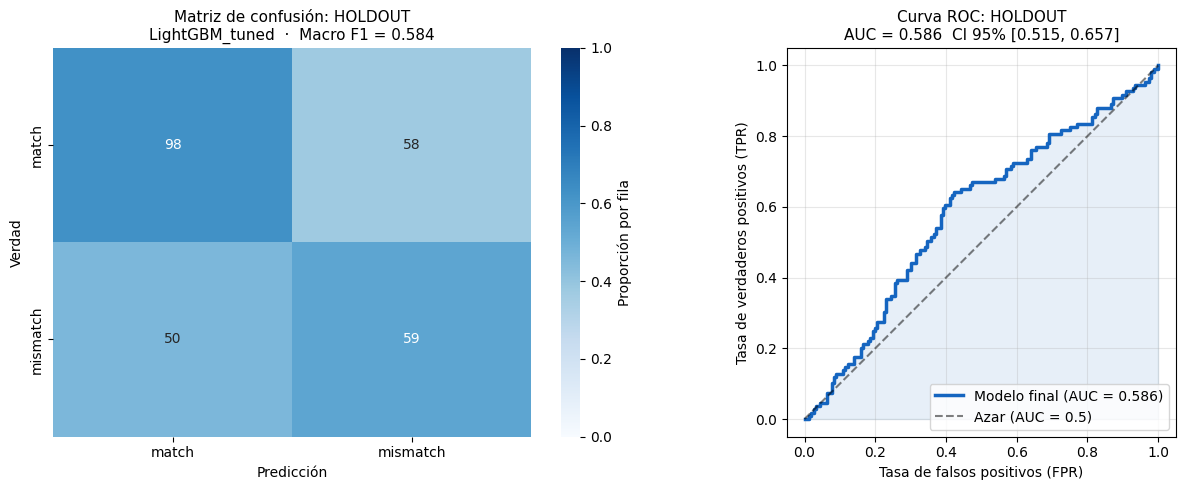

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm = confusion_matrix(y_ho, y_pred_ho)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
            xticklabels=['match', 'mismatch'], yticklabels=['match', 'mismatch'],
            ax=axes[0], vmin=0, vmax=1,
            cbar_kws={'label': 'Proporción por fila'})
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Verdad')
axes[0].set_title(f'Matriz de confusión: HOLDOUT\n{best_info["winner_name"]}  ·  Macro F1 = {f1m_m:.3f}', fontsize=11)

# Curva ROC
fpr, tpr, _ = roc_curve(y_ho, y_proba_ho)
axes[1].plot(fpr, tpr, linewidth=2.5, color='#1565c0', label=f'Modelo final (AUC = {auc_m:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#1565c0')
axes[1].set_xlabel('Tasa de falsos positivos (FPR)')
axes[1].set_ylabel('Tasa de verdaderos positivos (TPR)')
axes[1].set_title(f'Curva ROC: HOLDOUT\nAUC = {auc_m:.3f}  CI 95% [{auc_lo:.3f}, {auc_hi:.3f}]', fontsize=11)
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
fig_path = FIGURES_DIR / '06_holdout_confusion_and_roc.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

## 10. Análisis por sujeto del holdout

Se calculan métricas por sujeto para ver si el desempeño es consistente o si hay sujetos que dominan el promedio.

In [11]:
per_subject = []
for s in np.unique(groups_ho):
    mask = groups_ho == s
    y_true_s = y_ho[mask]
    y_pred_s = y_pred_ho[mask]
    y_proba_s = y_proba_ho[mask]

    n_match = sum(y_true_s == 0)
    n_mism  = sum(y_true_s == 1)

    per_subject.append({
        'subject':  s,
        'n_epochs': len(y_true_s),
        'n_match':  int(n_match),
        'n_mismatch': int(n_mism),
        'accuracy': accuracy_score(y_true_s, y_pred_s),
        'f1_macro': f1_score(y_true_s, y_pred_s, average='macro', zero_division=0),
        'roc_auc':  roc_auc_score(y_true_s, y_proba_s) if len(set(y_true_s)) > 1 else np.nan,
        'precision_match':    precision_score(y_true_s, y_pred_s, pos_label=0, zero_division=0),
        'recall_match':       recall_score(y_true_s, y_pred_s, pos_label=0, zero_division=0),
        'precision_mismatch': precision_score(y_true_s, y_pred_s, pos_label=1, zero_division=0),
        'recall_mismatch':    recall_score(y_true_s, y_pred_s, pos_label=1, zero_division=0),
    })

df_per_subject = pd.DataFrame(per_subject)
df_per_subject.to_csv(REPORTS_DIR / '06_per_subject_analysis.csv', index=False)

print('=== DESEMPEÑO POR SUJETO EN HOLDOUT ===\n')
print(df_per_subject.to_string(index=False))

print(f'\nMejor sujeto: {df_per_subject.loc[df_per_subject["f1_macro"].idxmax(), "subject"]} '
      f'(F1 = {df_per_subject["f1_macro"].max():.3f})')
print(f'Peor sujeto:  {df_per_subject.loc[df_per_subject["f1_macro"].idxmin(), "subject"]} '
      f'(F1 = {df_per_subject["f1_macro"].min():.3f})')
print(f'Rango inter-sujeto: {df_per_subject["f1_macro"].max() - df_per_subject["f1_macro"].min():.3f}')

=== DESEMPEÑO POR SUJETO EN HOLDOUT ===

subject  n_epochs  n_match  n_mismatch  accuracy  f1_macro  roc_auc  precision_match  recall_match  precision_mismatch  recall_mismatch
mu05erp        61       40          21  0.573770  0.425362 0.439286         0.634615      0.825000            0.222222         0.095238
mu17erp        41       24          17  0.609756  0.609524 0.539216         0.722222      0.541667            0.521739         0.705882
mu24erp        55       35          20  0.490909  0.490741 0.574286         0.684211      0.371429            0.388889         0.700000
mu27erp        37       18          19  0.567568  0.564706 0.602339         0.562500      0.500000            0.571429         0.631579
mu36erp        71       39          32  0.690141  0.682520 0.720353         0.697674      0.769231            0.678571         0.593750

Mejor sujeto: mu36erp (F1 = 0.683)
Peor sujeto:  mu05erp (F1 = 0.425)
Rango inter-sujeto: 0.257


## 11. Distribución de confianza en holdout

Se revisa la confianza del modelo usando max(p, 1-p). Lo que se quiere es ver si los errores tienden a ocurrir cerca de 0.5 (casos ambiguos) o si hay errores con alta confianza, lo cual puede indicar problemas de calibración o límites del modelo en ciertos sujetos/ensayos.

 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/06_confidence_and_calibration.png


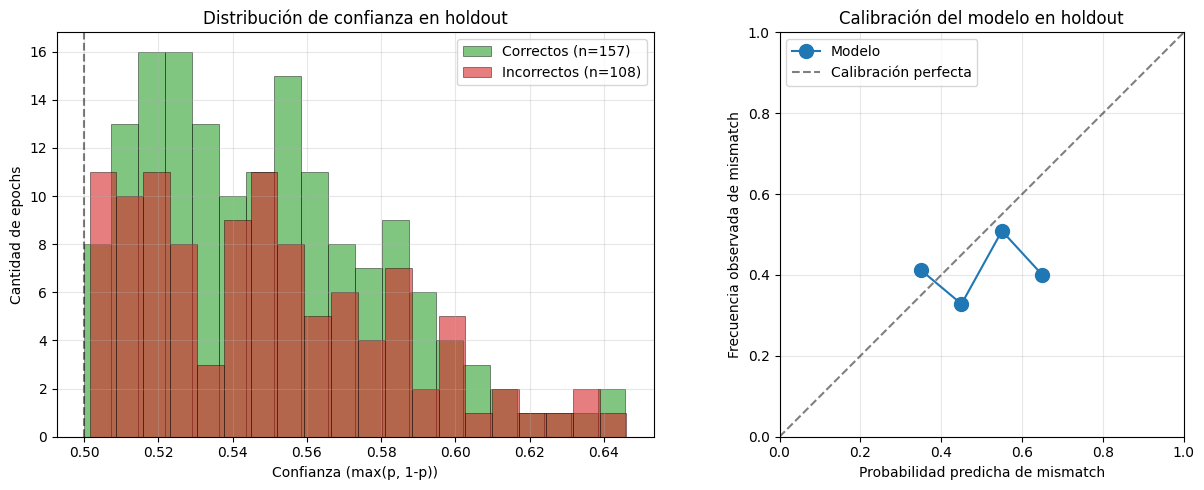

In [12]:
df_holdout_full = pd.DataFrame({
    'subject':  groups_ho,
    'y_true':   y_ho,
    'y_pred':   y_pred_ho,
    'y_proba':  y_proba_ho,
    'correct':  (y_ho == y_pred_ho).astype(int),
})
df_holdout_full['confidence'] = np.maximum(df_holdout_full['y_proba'], 1 - df_holdout_full['y_proba'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución de confianza por correcto/incorrecto
for label, color, mask in [('Correctos', 'tab:green', df_holdout_full['correct']==1),
                            ('Incorrectos', 'tab:red', df_holdout_full['correct']==0)]:
    axes[0].hist(df_holdout_full.loc[mask, 'confidence'], bins=20, alpha=0.6,
                 color=color, label=f'{label} (n={mask.sum()})', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Confianza (max(p, 1-p))')
axes[0].set_ylabel('Cantidad de epochs')
axes[0].set_title('Distribución de confianza en holdout')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].axvline(0.5, color='k', linestyle='--', alpha=0.5)

# Calibración: probabilidad predicha vs probabilidad observada
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2
obs_freq = []
for i in range(n_bins):
    mask = (df_holdout_full['y_proba'] >= bin_edges[i]) & (df_holdout_full['y_proba'] < bin_edges[i+1])
    if mask.sum() > 0:
        obs_freq.append(df_holdout_full.loc[mask, 'y_true'].mean())
    else:
        obs_freq.append(np.nan)

axes[1].plot(bin_mids, obs_freq, 'o-', markersize=10, color='tab:blue', label='Modelo')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibración perfecta')
axes[1].set_xlabel('Probabilidad predicha de mismatch')
axes[1].set_ylabel('Frecuencia observada de mismatch')
axes[1].set_title('Calibración del modelo en holdout')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_aspect('equal')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
fig_path = FIGURES_DIR / '06_confidence_and_calibration.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

## 12. Curvas de aprendizaje

Se calcula una curva de aprendizaje en el conjunto CV usando GroupKFold por sujeto. Esto ayuda a observar cómo cambian las métricas de entrenamiento y validación cuando aumenta la cantidad de datos usados para entrenar, y sirve como diagnóstico general del comportamiento del modelo.

 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/06_learning_curves.png


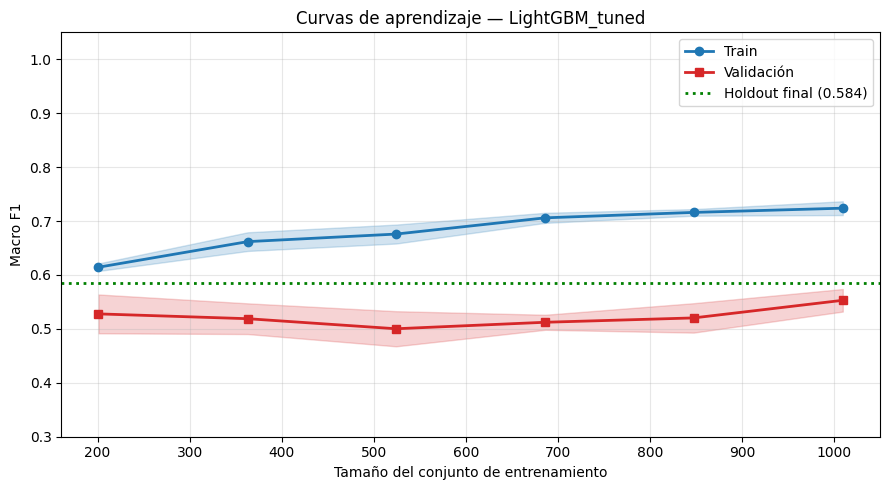


Gap train-validación en tamaño completo: 0.171
  -> Varianza moderada: Aceptable.
  -> Validación aceptable.


In [13]:
from sklearn.model_selection import GroupKFold

# Tomar una copia limpia del pipeline
lc_pipeline = clone(best_model)

train_sizes_abs, train_scores, val_scores = learning_curve(
    lc_pipeline, X_cv, y_cv,
    groups=groups_cv,
    cv=GroupKFold(n_splits=5),
    train_sizes=np.linspace(0.2, 1.0, 6),
    scoring='f1_macro',
    n_jobs=1,
    random_state=SEED
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes_abs, train_mean, 'o-', color='tab:blue', label='Train', linewidth=2)
ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.2, color='tab:blue')
ax.plot(train_sizes_abs, val_mean, 's-', color='tab:red', label='Validación', linewidth=2)
ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.2, color='tab:red')
ax.axhline(holdout_metrics['f1_macro']['mean'], color='green', linestyle=':',
           linewidth=2, label=f'Holdout final ({holdout_metrics["f1_macro"]["mean"]:.3f})')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('Macro F1')
ax.set_title(f'Curvas de aprendizaje — {best_info["winner_name"]}')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0.3, 1.05)

plt.tight_layout()
fig_path = FIGURES_DIR / '06_learning_curves.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

# Diagnóstico textual
gap = train_mean[-1] - val_mean[-1]
print(f'\nGap train-validación en tamaño completo: {gap:.3f}')
if gap > 0.2:
    print('  -> Alta varianza: Se puede considerar más regularización.')
elif gap > 0.05:
    print('  -> Varianza moderada: Aceptable.')
else:
    print('  -> Bajo gap: Osea modelo bien balanceado.')

if val_mean[-1] < 0.55:
    print('  -> Validación baja.')
else:
    print('  -> Validación aceptable.')

## 13. Validación LOSO (Leave-One-Subject-Out)

Se ejecuta Leave-One-Subject-Out para obtener una estimación del desempeño por sujeto: en cada fold se entrena con todos los sujetos menos uno y se evalúa en el sujeto restante. Esto permite observar variación entre sujetos y no solo un promedio global. Si RUN_LOSO está en False, esta sección se omite.

In [14]:
if RUN_LOSO:
    # Conjunto completo (CV y holdout) para LOSO honesto
    X_all = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
    y_all = df['label'].values
    groups_all = df['subject_id'].values

    logo = LeaveOneGroupOut()
    n_splits = logo.get_n_splits(X_all, y_all, groups_all)
    print(f'LOSO: {n_splits} folds (uno por sujeto)\n')

    loso_results = []
    for i, (train_idx, test_idx) in enumerate(tqdm(logo.split(X_all, y_all, groups_all), total=n_splits, desc='LOSO')):
        test_subject = groups_all[test_idx][0]
        X_tr, X_te = X_all[train_idx], X_all[test_idx]
        y_tr, y_te = y_all[train_idx], y_all[test_idx]

        model_fold = clone(best_model)
        model_fold.fit(X_tr, y_tr)
        y_pred_te  = model_fold.predict(X_te)
        try:
            y_proba_te = model_fold.predict_proba(X_te)[:, 1]
        except Exception:
            y_proba_te = None

        loso_results.append({
            'subject': test_subject,
            'n_epochs': len(y_te),
            'accuracy': accuracy_score(y_te, y_pred_te),
            'f1_macro': f1_score(y_te, y_pred_te, average='macro', zero_division=0),
            'roc_auc': roc_auc_score(y_te, y_proba_te) if y_proba_te is not None and len(set(y_te)) > 1 else np.nan,
        })

    df_loso = pd.DataFrame(loso_results)
    df_loso.to_csv(REPORTS_DIR / '06_loso_results.csv', index=False)

    print(f'\n=== RESULTADOS LOSO con 29 sujetos ===')
    print(f'  Macro F1:  {df_loso["f1_macro"].mean():.3f} ± {df_loso["f1_macro"].std():.3f}')
    print(f'  Accuracy:  {df_loso["accuracy"].mean():.3f} ± {df_loso["accuracy"].std():.3f}')
    print(f'  ROC-AUC:   {df_loso["roc_auc"].mean():.3f} ± {df_loso["roc_auc"].std():.3f}')
    print(f'\n  Mejor sujeto: {df_loso.loc[df_loso["f1_macro"].idxmax(), "subject"]} '
          f'(F1 = {df_loso["f1_macro"].max():.3f})')
    print(f'  Peor sujeto:  {df_loso.loc[df_loso["f1_macro"].idxmin(), "subject"]} '
          f'(F1 = {df_loso["f1_macro"].min():.3f})')
else:
    df_loso = None
    print('LOSO saltado (RUN_LOSO=False).')

LOSO: 29 folds (uno por sujeto)



LOSO:   0%|          | 0/29 [00:00<?, ?it/s]


=== RESULTADOS LOSO con 29 sujetos ===
  Macro F1:  0.514 ± 0.091
  Accuracy:  0.556 ± 0.096
  ROC-AUC:   0.545 ± 0.096

  Mejor sujeto: mu29erp (F1 = 0.706)
  Peor sujeto:  mu04erp (F1 = 0.303)


 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/06_loso_per_subject.png


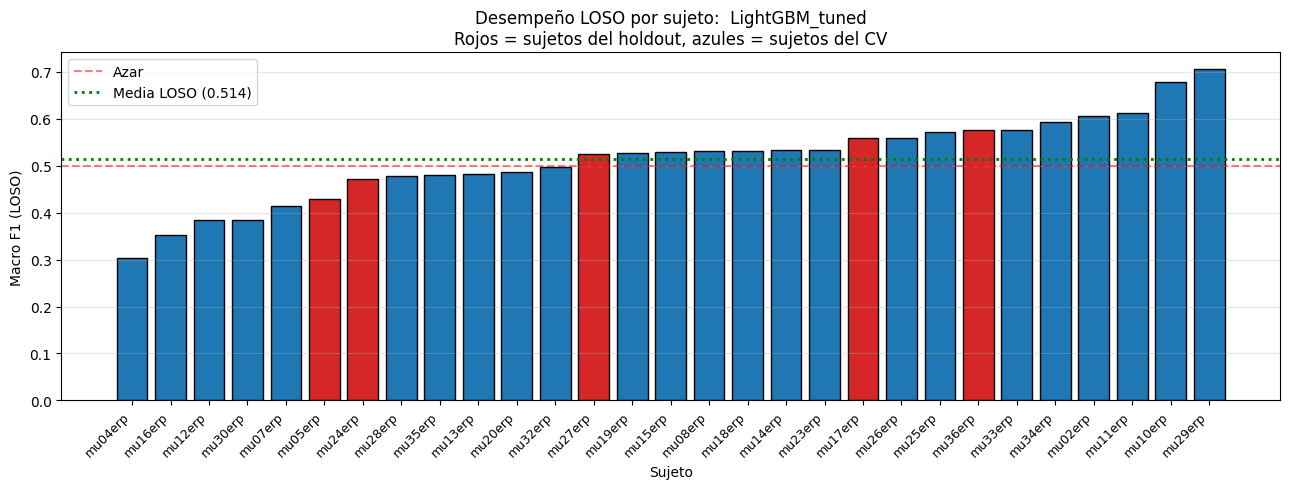

In [15]:
if df_loso is not None:
    fig, ax = plt.subplots(figsize=(13, 5))
    df_loso_sorted = df_loso.sort_values('f1_macro').reset_index(drop=True)
    colors = ['tab:red' if s in split_info['holdout_subjects'] else 'tab:blue' for s in df_loso_sorted['subject']]
    ax.bar(range(len(df_loso_sorted)), df_loso_sorted['f1_macro'], color=colors, edgecolor='black')
    ax.set_xticks(range(len(df_loso_sorted)))
    ax.set_xticklabels(df_loso_sorted['subject'], rotation=45, ha='right', fontsize=9)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Azar')
    ax.axhline(df_loso['f1_macro'].mean(), color='green', linestyle=':',
               linewidth=2, label=f'Media LOSO ({df_loso["f1_macro"].mean():.3f})')
    ax.set_xlabel('Sujeto')
    ax.set_ylabel('Macro F1 (LOSO)')
    ax.set_title(f'Desempeño LOSO por sujeto:  {best_info["winner_name"]}\n'
                 f'Rojos = sujetos del holdout, azules = sujetos del CV')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig_path = FIGURES_DIR / '06_loso_per_subject.png'
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    print(f' Guardado: {fig_path}')
    plt.show()

## 14. Tabla consolidada de resultados

In [16]:
# Cargar resultados de notebooks anteriores
df_baselines = pd.read_csv(REPORTS_DIR / '03_baselines_results.csv')
df_models04  = pd.read_csv(REPORTS_DIR / '04_models_cv_comparison.csv')
df_final05   = pd.read_csv(REPORTS_DIR / '05_final_comparison.csv')

master = []

# Baselines (CV)
for _, r in df_baselines.iterrows():
    master.append({
        'fase': '03_baseline',
        'modelo': r['modelo'],
        'macro_F1_CV':      f'{r["f1_macro"]:.3f}',
        'macro_F1_CV_CI':   f'[{r["f1_macro_lo"]:.3f}, {r["f1_macro_hi"]:.3f}]',
        'macro_F1_HOLDOUT': '—',
        'AUC_HOLDOUT':      '—',
    })

# Modelos sin tuning (CV)
for _, r in df_models04.iterrows():
    master.append({
        'fase': '04_sin_tuning',
        'modelo': r['modelo'],
        'macro_F1_CV':      f'{r["f1_macro"]:.3f}',
        'macro_F1_CV_CI':   f'[{r["f1_macro_lo"]:.3f}, {r["f1_macro_hi"]:.3f}]',
        'macro_F1_HOLDOUT': '—',
        'AUC_HOLDOUT':      '—',
    })

# Modelos tuneados (CV) — pero solo los que fueron tuneados
tuned_rows = df_final05[df_final05['tipo'] == 'TUNEADO']
for _, r in tuned_rows.iterrows():
    master.append({
        'fase': '05_tuneado',
        'modelo': r['modelo'],
        'macro_F1_CV':      f'{r["f1_macro"]:.3f}',
        'macro_F1_CV_CI':   f'[{r["f1_macro_lo"]:.3f}, {r["f1_macro_hi"]:.3f}]',
        'macro_F1_HOLDOUT': '—',
        'AUC_HOLDOUT':      '—',
    })

# Modelo final en HOLDOUT (este notebook)
master.append({
    'fase': '06_final_holdout',
    'modelo': f' {best_info["winner_name"]} (HOLDOUT)',
    'macro_F1_CV':       f'{best_info["cv_f1_macro"]:.3f}',
    'macro_F1_CV_CI':    f'[{best_info["cv_f1_macro_ci"][0]:.3f}, {best_info["cv_f1_macro_ci"][1]:.3f}]',
    'macro_F1_HOLDOUT':  f'{f1m_m:.3f} [{f1m_lo:.3f}, {f1m_hi:.3f}]',
    'AUC_HOLDOUT':       f'{auc_m:.3f} [{auc_lo:.3f}, {auc_hi:.3f}]',
})

# LOSO si está
if df_loso is not None:
    master.append({
        'fase': '06_loso',
        'modelo': f'{best_info["winner_name"]} (LOSO 29 sujetos)',
        'macro_F1_CV':       f'{df_loso["f1_macro"].mean():.3f} ± {df_loso["f1_macro"].std():.3f}',
        'macro_F1_CV_CI':    '—',
        'macro_F1_HOLDOUT':  '—',
        'AUC_HOLDOUT':       f'{df_loso["roc_auc"].mean():.3f} ± {df_loso["roc_auc"].std():.3f}',
    })

df_master = pd.DataFrame(master)
df_master.to_csv(REPORTS_DIR / '06_master_results_table.csv', index=False)

print('=' * 95)
print('  TABLA MAESTRA')
print('=' * 95)
print(df_master.to_string(index=False))
print(f'\n Guardado: reports/06_master_results_table.csv')

  TABLA MAESTRA
            fase                                       modelo   macro_F1_CV macro_F1_CV_CI     macro_F1_HOLDOUT          AUC_HOLDOUT
     03_baseline                           Dummy (stratified)         0.498 [0.472, 0.527]                    —                    —
     03_baseline                        Dummy (most_frequent)         0.364 [0.352, 0.375]                    —                    —
     03_baseline          Heurístico ERP [LogReg, 2 features]         0.501 [0.473, 0.529]                    —                    —
     03_baseline Heurístico ERP extendido (De las 4 features)         0.516 [0.487, 0.542]                    —                    —
   04_sin_tuning                        LogisticRegression_L2         0.520 [0.494, 0.549]                    —                    —
   04_sin_tuning                                     LightGBM         0.518 [0.491, 0.545]                    —                    —
   04_sin_tuning                                     